In [1]:
#calculate and plot wind drought events in cool season of one year

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

import scipy.stats
import netCDF4 as nc
from datetime import datetime

In [2]:
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import cartopy.crs as ccrs
import cartopy
from mpl_toolkits.axes_grid1 import make_axes_locatable
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
                                LatitudeLocator, LongitudeLocator)

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [7]:
tfile = "/g/data/w42/dr6273/work/projects/Aus_energy/production_metrics/wind/capacity_factor/van_der_Wiel/wind_capacity_factor_van_der_Wiel_era5_hourly_2010_Aus.nc"
hourly = xr.open_dataset(tfile, chunks={"time": 24, "level": 2})
daily = hourly.coarsen(time=24).mean(keep_attrs=True).compute()

In [8]:
daily

<xarray.Dataset> Size: 37MB
Dimensions:          (time: 365, lat: 141, lon: 181)
Coordinates:
  * lon              (lon) float32 724B 110.0 110.2 110.5 ... 154.5 154.8 155.0
  * lat              (lat) float32 564B -10.0 -10.25 -10.5 ... -44.75 -45.0
  * time             (time) datetime64[ns] 3kB 2010-01-01T11:30:00 ... 2010-1...
Data variables:
    capacity_factor  (time, lat, lon) float32 37MB 0.0 0.0001027 ... 0.5307

In [9]:
cpf = daily.capacity_factor
lon = cpf.lon
lat = cpf.lat
tm = cpf.time

In [35]:
tme = np.arange(np.datetime64('2010-01-01'), np.datetime64('2011-01-01')) #all days

In [36]:
#first day of every month
import datetime
def get_first_date_of_month(year, month):
    return datetime.date(year, month, 1)

yr = 2010 #np.arange(1940,2024,1)

cc = 0
dtm = tme

for mth in range(0,12):
    dtm[cc] = get_first_date_of_month(yr,mth+1)
    cc = cc+1

In [12]:
#coolcp = cpf[120:304,60:101,120:161]#
coolcp = cpf[120:304,:,:]#May to oct

In [17]:
cp25 = np.percentile(np.mean(coolcp,axis=(1,2)),25) #25th percentile for each grid point

In [37]:
dtm[120:304]

array(['2010-05-01', '2010-05-02', '2010-05-03', '2010-05-04',
       '2010-05-05', '2010-05-06', '2010-05-07', '2010-05-08',
       '2010-05-09', '2010-05-10', '2010-05-11', '2010-05-12',
       '2010-05-13', '2010-05-14', '2010-05-15', '2010-05-16',
       '2010-05-17', '2010-05-18', '2010-05-19', '2010-05-20',
       '2010-05-21', '2010-05-22', '2010-05-23', '2010-05-24',
       '2010-05-25', '2010-05-26', '2010-05-27', '2010-05-28',
       '2010-05-29', '2010-05-30', '2010-05-31', '2010-06-01',
       '2010-06-02', '2010-06-03', '2010-06-04', '2010-06-05',
       '2010-06-06', '2010-06-07', '2010-06-08', '2010-06-09',
       '2010-06-10', '2010-06-11', '2010-06-12', '2010-06-13',
       '2010-06-14', '2010-06-15', '2010-06-16', '2010-06-17',
       '2010-06-18', '2010-06-19', '2010-06-20', '2010-06-21',
       '2010-06-22', '2010-06-23', '2010-06-24', '2010-06-25',
       '2010-06-26', '2010-06-27', '2010-06-28', '2010-06-29',
       '2010-06-30', '2010-07-01', '2010-07-02', '2010-

In [15]:
nevmay = np.zeros([141,181]) #no.of events
nevjun = np.zeros([141,181])
nevjul = np.zeros([141,181])
nevaug = np.zeros([141,181])
nevsep = np.zeros([141,181])
nevoct = np.zeros([141,181])
nevcool = np.zeros([141,181])

In [27]:
for ii in range(0,141):
    for jj in range(0,181):
        xx = np.array(coolcp[:,ii,jj].where(coolcp[:,ii,jj] < cp25)) #cool season
        xy = np.argwhere(~np.isnan(xx))
        df = np.ediff1d(xy)
        nevcool[ii,jj] = len(df[df>=3])

        # xx = np.array(coolcp[120:151,ii,jj].where(coolcp[120:151,ii,jj] < cp25)) #may
        # xy = np.argwhere(~np.isnan(xx))
        # df = np.ediff1d(xy)
        # nevmay[ii,jj] = len(df[df>=3]) 
        
        # xx = np.array(coolcp[151:181,ii,jj].where(coolcp[151:181,ii,jj] < cp25)) #jun
        # xy = np.argwhere(~np.isnan(xx))
        # df = np.ediff1d(xy)
        # nevjun[ii,jj] = len(df[df>=3]) 
        
        # xx = np.array(coolcp[181:212,ii,jj].where(coolcp[181:212,ii,jj] < cp25)) #jul
        # xy = np.argwhere(~np.isnan(xx))
        # df = np.ediff1d(xy)
        # nevjul[ii,jj] = len(df[df>=3])
        
        # xx = np.array(coolcp[212:243,ii,jj].where(coolcp[212:243,ii,jj] < cp25)) #aug
        # xy = np.argwhere(~np.isnan(xx))
        # df = np.ediff1d(xy)
        # nevaug[ii,jj] = len(df[df>=3])
        
        # xx = np.array(coolcp[243:273,ii,jj].where(coolcp[243:273,ii,jj] < cp25)) #may
        # xy = np.argwhere(~np.isnan(xx))
        # df = np.ediff1d(xy)
        # nevsep[ii,jj] = len(df[df>=3])
        
        # xx = np.array(coolcp[273:304,ii,jj].where(coolcp[273:304,ii,jj] < cp25)) #may
        # xy = np.argwhere(~np.isnan(xx))
        # df = np.ediff1d(xy)
        # nevoct[ii,jj] = len(df[df>=3])

Text(0.5, 1.0, 'No. of wind-lull events: 2010 May-Oct')

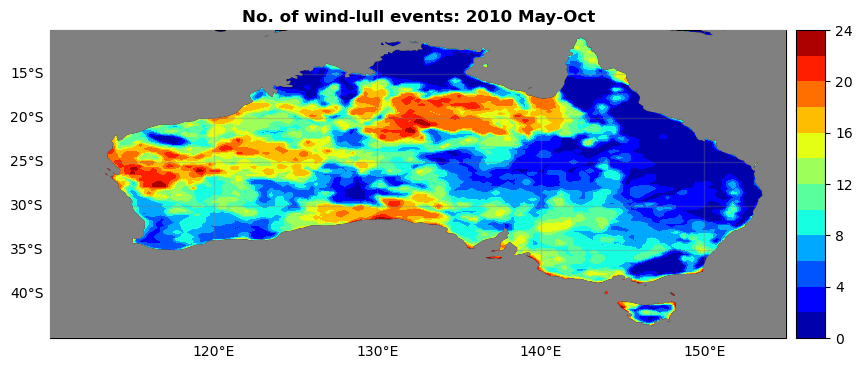

In [32]:
fig = plt.figure(figsize=[10,4])
ax = fig.add_subplot(111, projection=ccrs.PlateCarree(central_longitude=180))
levels = np.arange(0,26,2)

cf = plt.contourf(lon,lat,nevcool,levels=levels,transform=ccrs.PlateCarree(),cmap="jet")
ax.add_feature(cartopy.feature.OCEAN, zorder=100, color='grey')
ax.set_extent([110,155,-45,-10], ccrs.PlateCarree())

xl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=1, color='gray', alpha=0.3, linestyle='-')
xl.xlabel_style = {'size': 10, 'color': 'k', 'rotation':0}
xl.ylabel_style = {'size': 10, 'color': 'k', 'rotation':0}
xl.top_labels = False
xl.right_labels = False
xl.xformatter = LongitudeFormatter()
xl.yformatter = LatitudeFormatter() 

ax.coastlines()

divider = make_axes_locatable(ax)
ax_cb = divider.new_horizontal(size="4%", pad=0.1, axes_class=plt.Axes)
fig.add_axes(ax_cb)
cx = plt.colorbar(cf, cax=ax_cb)
cx.ax.tick_params(labelsize=10) 
ax.set_aspect('auto', adjustable=None)
title = "No. of wind-lull events: 2010 May-Oct"
ax.set_title(title,size=12,fontweight='bold')
#plt.savefig('Windlull_events.jpg', dpi=300,bbox_inches='tight')

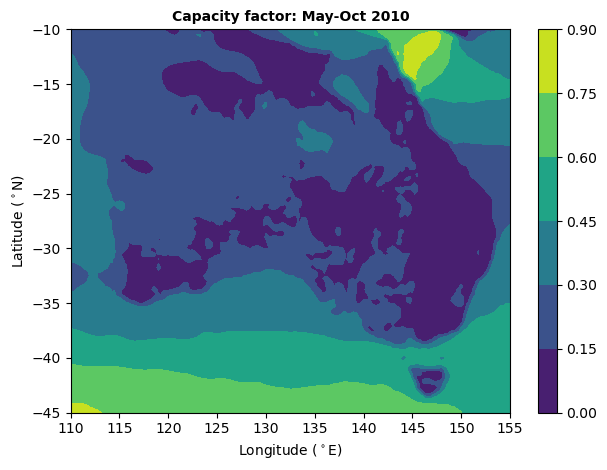

In [40]:
fig, ax = plt.subplots(1, 1)

levels = np.arange(0.0,9.0,1.0)
lon2d,lat2d = np.meshgrid(lon,lat)

cnf = ax.contourf(lon2d,lat2d,np.mean(cpf[150:304,:,:],axis=0))#,levels=levels,cmap="jet",vmin=0.0,vmax=8.0)
ax.set_title('Capacity factor: May-Oct 2010',fontsize=10,fontweight='bold')
#ax.set_ylim([-30,30])
ax.set_xlabel('Longitude ($^\circ$E)')
ax.set_ylabel('Latitude ($^\circ$N)')

#ax.clim([0.0, 1.0])
cb = fig.colorbar(cnf, ax=ax, orientation='vertical')
#cb.set_label('$kJ/kg$')
fig.tight_layout()